In [1]:
from library import SimpleMLP, Trainer
import jax
import jax.random as jr
import jax.numpy as jnp

print(jax.devices()) 
# Should be [CudaDevice(id=0)] if everything is installed well.
# as long as there is no error message, everything is fine, though

# 1. Setup
key = jr.PRNGKey(0)
x_key, y_key = jr.split(key)

x_train = jr.uniform(x_key, (1000, 1), minval=-jnp.pi, maxval=jnp.pi)
y_train = jnp.sin(x_train) + 0.1 * jr.normal(y_key, (1000, 1)) # Sine + noise
model = SimpleMLP(in_size=1, out_size=1, width_size=32, depth=3, key=key)
trainer = Trainer(model, lr=1e-3)

# 2. Train (Note how we pass x and y as separate args)
trained_model = trainer.fit(x_train, y_train, steps=1000)

[CudaDevice(id=0)]
Training SimpleMLP | Number of training data: 800 | Number of validation data: 200
Step    0 | Train loss: 0.6024 | Validation loss: 0.4595
Step  100 | Train loss: 0.0467 | Validation loss: 0.0487
Step  200 | Train loss: 0.0231 | Validation loss: 0.0174
Step  300 | Train loss: 0.0103 | Validation loss: 0.0117
Step  400 | Train loss: 0.0127 | Validation loss: 0.0113
Step  500 | Train loss: 0.0134 | Validation loss: 0.0117
Step  600 | Train loss: 0.0112 | Validation loss: 0.0126
Step  700 | Train loss: 0.0143 | Validation loss: 0.0089
Step  800 | Train loss: 0.0110 | Validation loss: 0.0104
Step  900 | Train loss: 0.0086 | Validation loss: 0.0089
Step  999 | Train loss: 0.0082 | Validation loss: 0.0100


(50, 1)


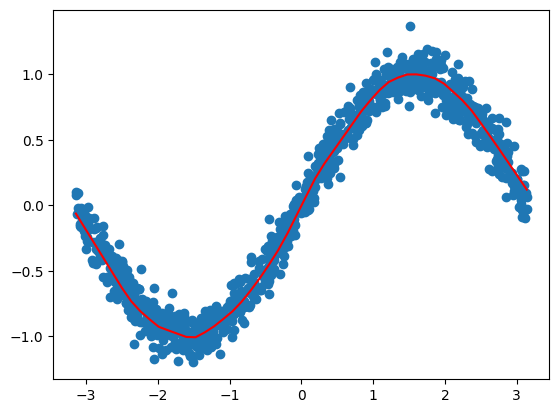

In [2]:
import matplotlib.pyplot as plt

# 3. Predict
test_input = jnp.linspace(-jnp.pi, jnp.pi).reshape(-1, 1)
print(test_input.shape)
prediction = trained_model(test_input)
plt.scatter(x_train, y_train)
plt.plot(test_input, prediction, color="red")

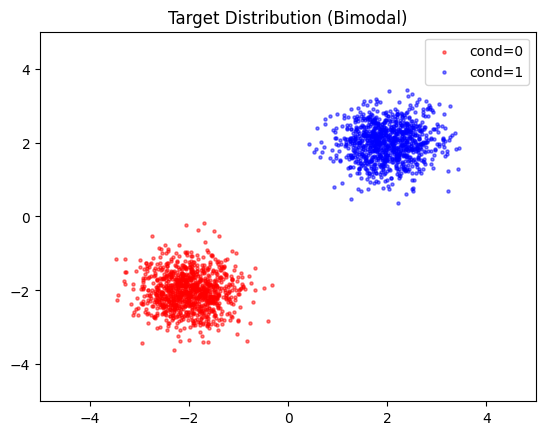

In [3]:
def generate_bimodal_data(key, n_samples=2000):
    k1, k2, k3 = jr.split(key, 3)
    # 50% from cluster A, 50% from cluster B
    selector = jr.bernoulli(k1, 0.5, (n_samples, 1))
    
    cluster_a = jr.normal(k2, (n_samples, 2)) * 0.5 + jnp.array([2.0, 2.0])
    cluster_b = jr.normal(k3, (n_samples, 2)) * 0.5 + jnp.array([-2.0, -2.0])
    
    x_train = jnp.where(selector, cluster_a, cluster_b)
    cond_train = selector.astype(jnp.float32)
    return x_train, cond_train

key = jr.PRNGKey(42)
x_data, cond_data = generate_bimodal_data(key)

# Visualize the "Ground Truth"
plt.scatter(x_data[cond_data[:,0]==0, 0], x_data[cond_data[:,0]==0, 1], color="red", label="cond=0", s=5, alpha=0.5)
plt.scatter(x_data[cond_data[:,0]==1, 0], x_data[cond_data[:,0]==1, 1], color="blue", label="cond=1", s=5, alpha=0.5)
plt.title("Target Distribution (Bimodal)")
plt.legend()
plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.show()

In [4]:
from library import CNF

# 1. Initialize CNF
cnf_model = CNF(data_dim=2, condition_dim=1, width_size = 32, depth = 2, key=jr.PRNGKey(7))

# 2. Setup Trainer
trainer = Trainer(cnf_model, lr=1e-3)

# 3. Fit (This might take a minute depending on your PC)
trained_cnf = trainer.fit(x_data, cond_data, steps=1000, batch_size=128)

Training CNF | Number of training data: 1600 | Number of validation data: 400
Step    0 | Train loss: 6.5396 | Validation loss: 6.4936
Step  100 | Train loss: 2.8212 | Validation loss: 2.8655
Step  200 | Train loss: 2.2364 | Validation loss: 2.2412
Step  300 | Train loss: 1.9155 | Validation loss: 1.8827
Step  400 | Train loss: 1.6269 | Validation loss: 1.7183
Step  500 | Train loss: 1.5330 | Validation loss: 1.4480
Step  600 | Train loss: 1.4583 | Validation loss: 1.2428
Step  700 | Train loss: 1.4546 | Validation loss: 1.3287
Step  800 | Train loss: 1.4483 | Validation loss: 1.5743
Step  900 | Train loss: 1.3624 | Validation loss: 1.5519
Step  999 | Train loss: 1.5077 | Validation loss: 1.4242


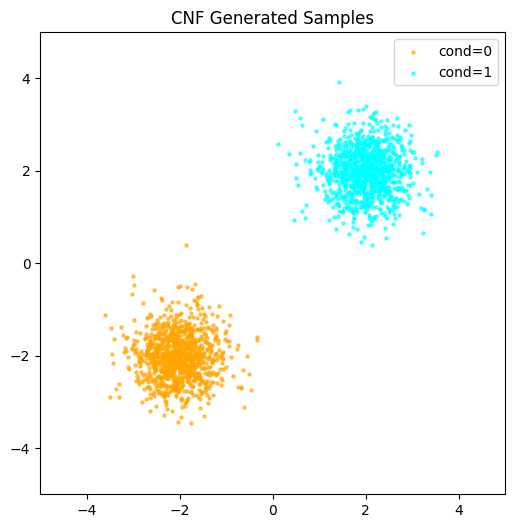

In [5]:
test_key = jr.PRNGKey(42)

# Generate 1000 samples from the learned prior through the ODE (either with cond=0 or cond=1 separately)
samples_0, _ = trained_cnf.multi_sample_and_log_prob(
    key=test_key, 
    cond=jnp.array([0]),
    n_samples=1000
)
samples_1, _ = trained_cnf.multi_sample_and_log_prob(
    key=test_key, 
    cond=jnp.array([1]),
    n_samples=1000
)

# Plot the generated points
plt.figure(figsize=(6, 6))
plt.scatter(samples_0[:, 0], samples_0[:, 1], s=5, color='orange', label="cond=0", alpha=0.6)
plt.scatter(samples_1[:, 0], samples_1[:, 1], s=5, color='cyan', label="cond=1", alpha=0.6)
plt.title("CNF Generated Samples")
plt.legend()
plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.show()

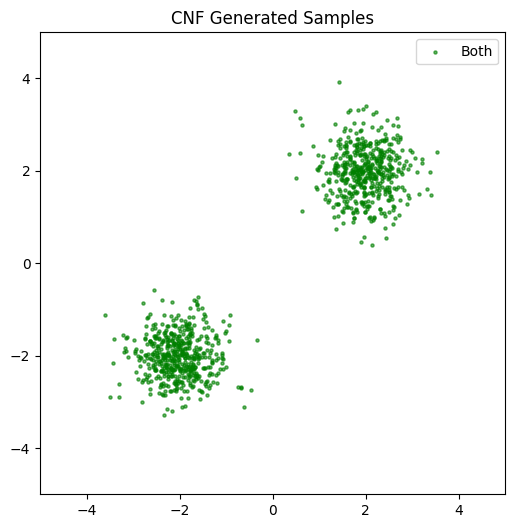

In [6]:
test_key = jr.PRNGKey(42)

# Generate 1000 samples from the learned prior through the ODE (either with cond=0 or cond=1 separately)
samples_mixed, _ = trained_cnf.multi_sample_and_log_prob(
    key=test_key, 
    cond=jr.bernoulli(key, p=0.5, shape=(1000, 1)).astype(jnp.float32),
    n_samples=1000
)

# Plot the generated points
plt.figure(figsize=(6, 6))
plt.scatter(samples_mixed[:, 0], samples_mixed[:, 1], s=5, color='green', label="Both", alpha=0.6)
plt.title("CNF Generated Samples")
plt.legend()
plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.show()

Moons: (10000, 2), Labels: (10000, 1)


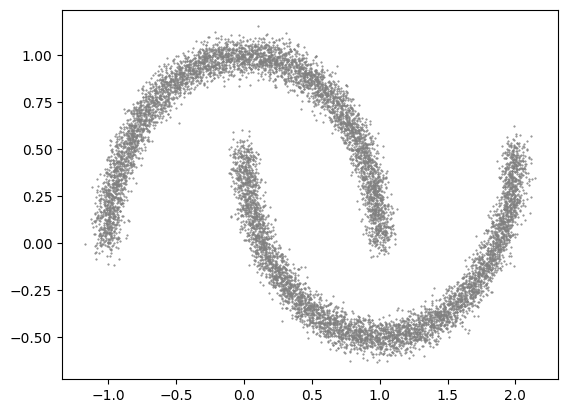

In [7]:
from sklearn.datasets import make_moons
import jax.numpy as jnp

# 1. Generate using sklearn
x_np, y_np = make_moons(n_samples=10_000, noise=0.05, random_state=42)

# 2. Convert to JAX arrays
x_data = jnp.array(x_np)
cond_data = jnp.array(y_np)[:, jnp.newaxis].astype(jnp.float32)

print(f"Moons: {x_data.shape}, Labels: {cond_data.shape}")
plt.scatter(x_data[:, 0], x_data[:, 1],color="grey",marker=".",s=1)

In [8]:
# Not as pretty as the optimized plot we had, but good enough :)
# Uncomment once you managed to train the CNF on the moons example above.
#fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(8,10))

#tvals = jnp.linspace(0,1,num=6)
#for it, t in enumerate(tvals):
#    samples_all, _ = trained_cnf.multi_sample_and_log_prob(jr.PRNGKey(0),jr.bernoulli(key, p=0.5, shape=(5000, 1)).astype(jnp.float32), 5000, tmax=t)
#    axs[it//2, it%2].scatter(samples_all[:, 0], samples_all[:, 1], color='grey', s=1, marker='.')
#    axs[it//2, it%2].set_xlim(-2.5,2.5)
#    axs[it//2, it%2].set_ylim(-2.5,2.5)
#plt.show()